# Exploratory Data Analysis — CA_1 Retail Demand

## Objective

This notebook explores historical retail demand for the CA_1 store using the
processed dataset created during the data preparation stage.

The objective is to understand the major patterns that may influence product
demand before developing forecasting models.

The analysis investigates:

- Overall demand trends over time
- Category and department sales patterns
- Product-level demand characteristics
- Zero and intermittent demand
- Weekly and calendar effects
- Event and holiday effects
- SNAP-related demand patterns
- Product pricing and price changes
- Product availability

The findings from this analysis will guide feature engineering, baseline
selection, and forecasting model development.

In [1]:
# ---------------------------------------------------------
# Import libraries
# ---------------------------------------------------------
# Path is used to construct project paths without hardcoding
# the absolute location of the repository on the computer.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Define project paths
# ---------------------------------------------------------
# This notebook is stored inside the `notebooks` directory.
# Its parent directory therefore represents the project root.

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

processed_file = (
    PROCESSED_DATA_DIR / "ca1_model_data.parquet"
)


# ---------------------------------------------------------
# Verify that the processed checkpoint exists
# ---------------------------------------------------------
# The EDA notebook depends on the validated Parquet dataset
# created in 01_data_inspection.ipynb.

print("Project root:", PROJECT_ROOT)
print("Processed dataset:", processed_file)
print("Dataset exists:", processed_file.exists())

Project root: C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence
Processed dataset: C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence\data\processed\ca1_model_data.parquet
Dataset exists: True


In [2]:
# ---------------------------------------------------------
# Load the processed analytical dataset
# ---------------------------------------------------------
# All raw-data preparation, reshaping, joins, and integrity
# checks were completed in 01_data_inspection.ipynb.
#
# Starting from the Parquet checkpoint keeps this notebook
# focused on exploratory analysis and avoids rebuilding the
# ~5.9 million-row dataset every time.

df = pd.read_parquet(
    processed_file,
    engine="pyarrow"
)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 5,918,109
Columns: 21


In [3]:
# ---------------------------------------------------------
# Initial dataset sanity check
# ---------------------------------------------------------
# Before beginning EDA, verify the dataset dimensions,
# time coverage, product coverage, and store coverage.
#
# These checks help ensure that the EDA is operating on the
# intended CA_1 dataset rather than an incomplete or incorrect
# processed file.

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["date"].min(),
    "to",
    df["date"].max()
)

print(
    "Unique products:",
    f'{df["item_id"].nunique():,}'
)

print(
    "Unique stores:",
    df["store_id"].nunique()
)

print(
    "Total units sold:",
    f'{df["sales"].sum():,}'
)

print(
    "Available observations:",
    f'{df["is_available"].sum():,}'
)

Dataset shape: (5918109, 21)
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00
Unique products: 3,049
Unique stores: 1
Total units sold: 7,832,248
Available observations: 4,788,267


## 1. Overall Demand Over Time

The first analysis examines how total unit demand at the CA_1 store changes
over time.

Product-level sales are aggregated by date to create a store-level daily
demand time series. This provides an initial view of long-term trends,
seasonality, volatility, and unusual demand periods.

In [4]:
# ---------------------------------------------------------
# Aggregate product-level sales into daily store demand
# ---------------------------------------------------------
# The processed dataset contains one observation per
# item-store-day combination.
#
# Summing sales across all products for each date gives the
# total number of units sold by CA_1 on that day.

daily_sales = (
    df.groupby(
        "date",
        observed=True
    )["sales"]
    .sum()
    .reset_index(name="total_sales")
    .sort_values("date")
)

print("Daily observations:", f"{len(daily_sales):,}")

print(
    "Average daily sales:",
    f'{daily_sales["total_sales"].mean():,.2f}'
)

print(
    "Median daily sales:",
    f'{daily_sales["total_sales"].median():,.2f}'
)

print(
    "Minimum daily sales:",
    f'{daily_sales["total_sales"].min():,}'
)

print(
    "Maximum daily sales:",
    f'{daily_sales["total_sales"].max():,}'
)

daily_sales.head()

Daily observations: 1,941
Average daily sales: 4,035.16
Median daily sales: 3,918.00
Minimum daily sales: 0
Maximum daily sales: 6,948


,date,total_sales
0,2011-01-29,4337
1,2011-01-30,4155
2,2011-01-31,2816
3,2011-02-01,3051
4,2011-02-02,2630


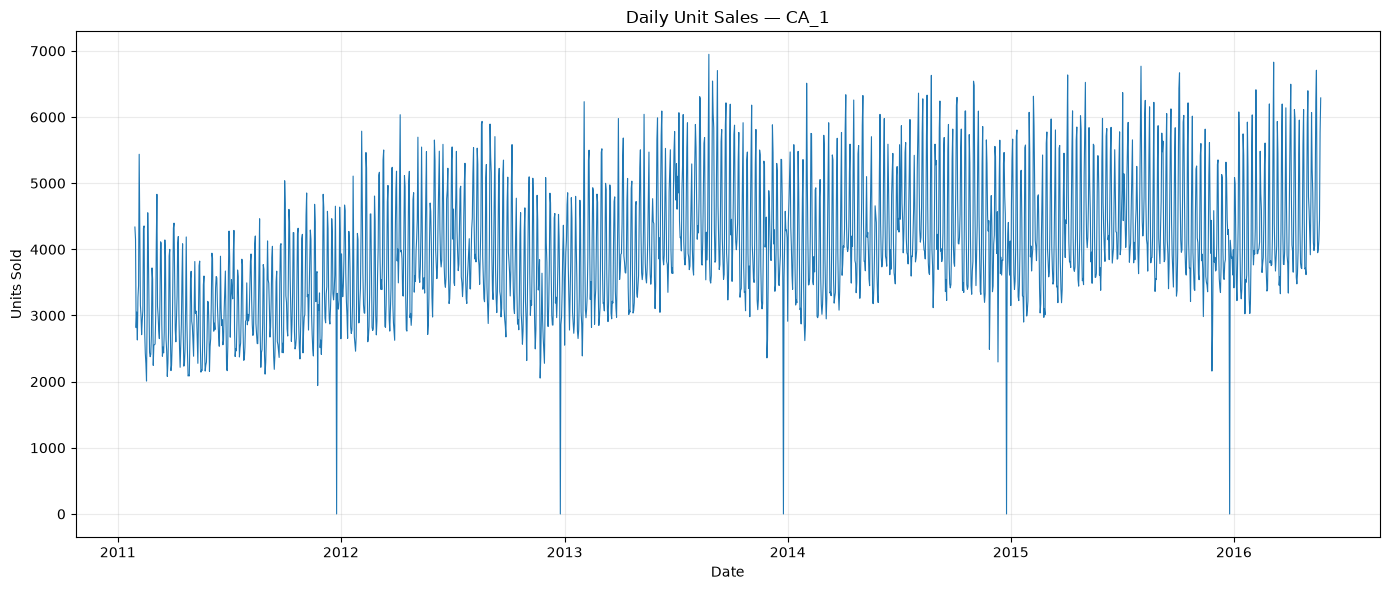

In [5]:
# ---------------------------------------------------------
# Visualize total daily demand over time
# ---------------------------------------------------------
# Plotting the complete daily series allows us to inspect:
#   - long-term demand trends,
#   - changes in volatility,
#   - possible seasonal patterns,
#   - unusually high or low demand periods.
#
# We deliberately start with the raw daily series before
# applying smoothing so that the true variability remains
# visible.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    linewidth=0.8
)

ax.set_title("Daily Unit Sales — CA_1")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------
# Investigate days with zero total store sales
# ---------------------------------------------------------
# CA_1 normally sells thousands of units per day, so a daily
# total of zero is unusual.
#
# Before treating this as a genuine demand collapse, we inspect
# the corresponding calendar information and product
# availability for any zero-sales dates.

zero_sales_days = daily_sales[
    daily_sales["total_sales"] == 0
].copy()

print(
    "Number of zero-sales days:",
    len(zero_sales_days)
)

zero_sales_days


Number of zero-sales days: 5


,date,total_sales
330,2011-12-25,0
696,2012-12-25,0
1061,2013-12-25,0
1426,2014-12-25,0
1791,2015-12-25,0


In [10]:
# ---------------------------------------------------------
# Inspect calendar information for zero-sales days
# ---------------------------------------------------------
# Calendar attributes may help explain whether these dates
# correspond to holidays, special events, or other unusual
# periods.

zero_sales_details = (
    df.loc[
        df["date"].isin(zero_sales_days["date"]),
        [
            "date",
            "weekday",
            "event_name_1",
            "event_type_1",
            "snap_CA",
        ]
    ]
    .drop_duplicates()
    .sort_values("date")
)

zero_sales_details

,date,weekday,event_name_1,event_type_1,snap_CA
1006170,2011-12-25,Sunday,Christmas,National,0
2122104,2012-12-25,Tuesday,Christmas,National,0
3234989,2013-12-25,Wednesday,Christmas,National,0
4347874,2014-12-25,Thursday,Christmas,National,0
5460759,2015-12-25,Friday,Christmas,National,0


In [11]:
# ---------------------------------------------------------
# Check product availability on zero-sales days
# ---------------------------------------------------------
# This determines whether zero store-level sales occurred
# because products were unavailable or despite products
# having recorded selling prices.

zero_day_availability = (
    df.loc[
        df["date"].isin(zero_sales_days["date"])
    ]
    .groupby(
        "date",
        observed=True
    )
    .agg(
        total_products=("item_id", "nunique"),
        available_products=("is_available", "sum"),
        total_sales=("sales", "sum"),
    )
    .reset_index()
)

zero_day_availability

,date,total_products,available_products,total_sales
0,2011-12-25,3049,1770,0
1,2012-12-25,3049,2221,0
2,2013-12-25,3049,2624,0
3,2014-12-25,3049,2982,0
4,2015-12-25,3049,3045,0


### Zero-Sales Day Investigation

Five days in the historical period recorded zero total sales at CA_1. All five
occurred on December 25 (Christmas Day), from 2011 through 2015.

The zero-sales observations do not appear to result from missing product
availability information. A substantial number of products had valid price
records on each of these dates, yet total store sales remained zero.

Therefore, these observations are retained as legitimate calendar-driven
demand patterns rather than treated as data errors or generic outliers.
Christmas is explicitly represented in the calendar features, allowing this
effect to be incorporated into later forecasting models.

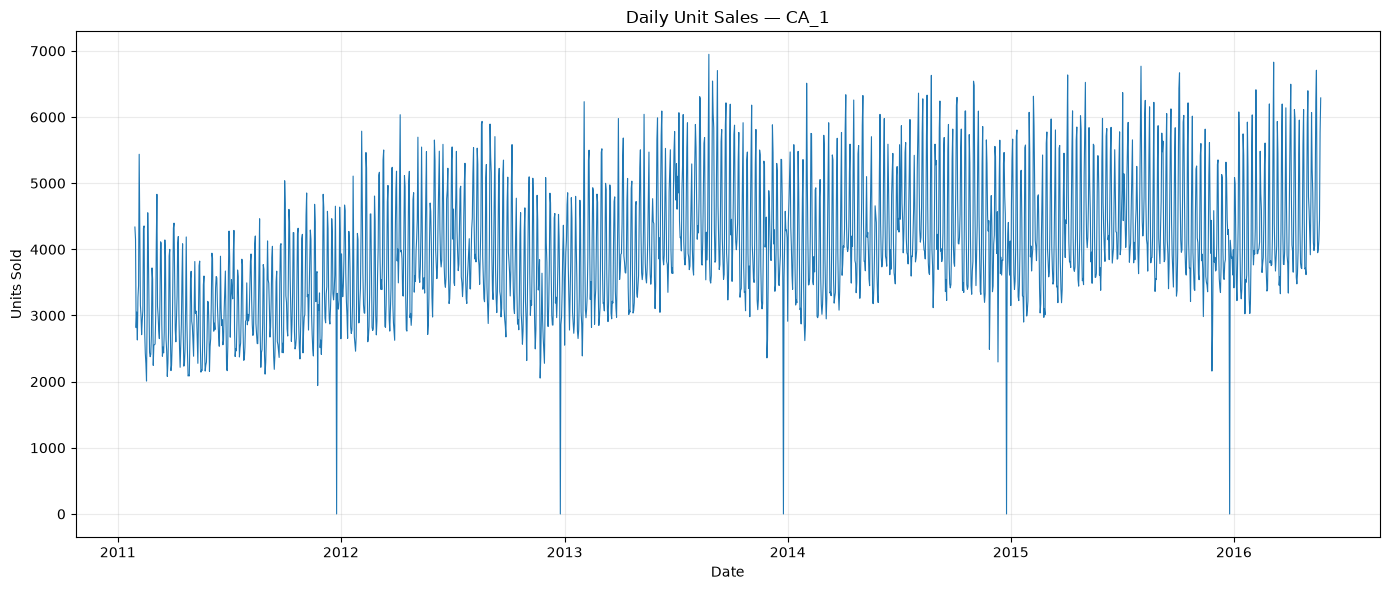

In [12]:
# ---------------------------------------------------------
# Visualize total daily demand over time
# ---------------------------------------------------------
# The complete daily series is plotted before applying any
# smoothing so that the original variability in store demand
# remains visible.
#
# The five Christmas zero-sales observations are intentionally
# retained because our investigation showed that they represent
# a recurring calendar-driven demand pattern rather than a
# general data-quality problem.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    linewidth=0.8
)

ax.set_title("Daily Unit Sales — CA_1")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")

# A light grid improves readability without dominating the plot.
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

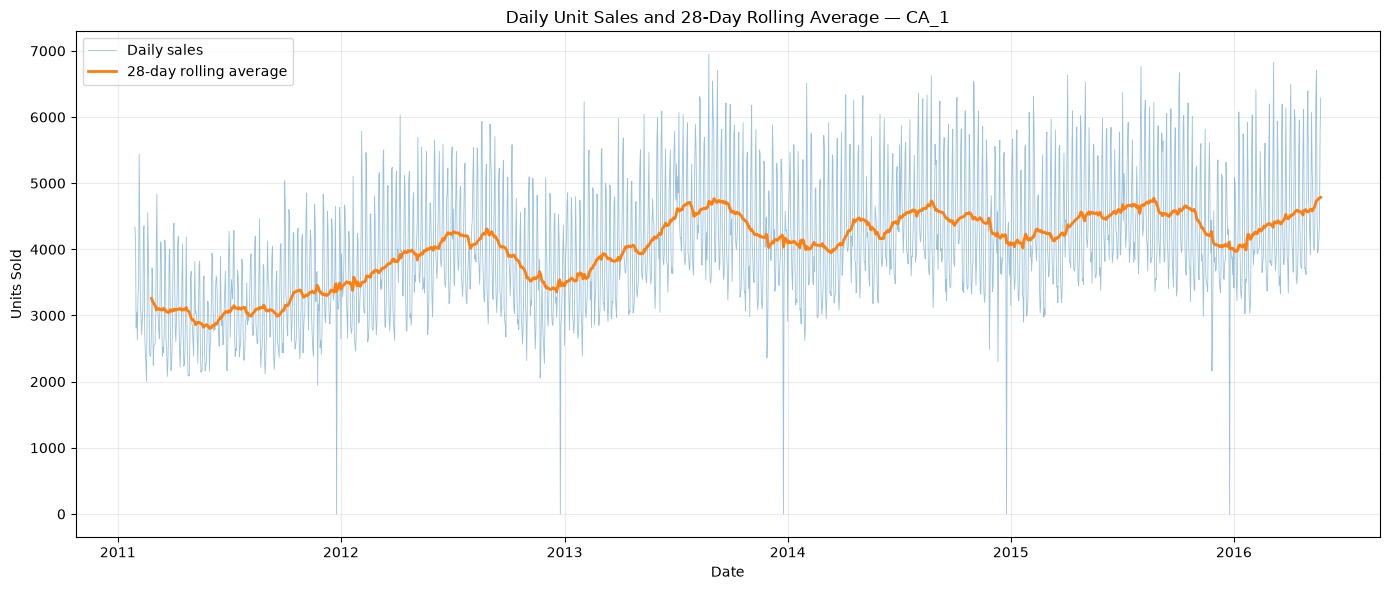

In [13]:
# ---------------------------------------------------------
# Calculate a 28-day rolling average of store demand
# ---------------------------------------------------------
# The raw daily series contains substantial short-term
# variation and appears to exhibit a recurring weekly pattern.
#
# A 28-day window represents exactly four weeks. This helps
# smooth weekly fluctuations while preserving medium- and
# long-term changes in the overall demand level.

daily_sales["rolling_mean_28d"] = (
    daily_sales["total_sales"]
    .rolling(
        window=28,
        min_periods=28
    )
    .mean()
)


# ---------------------------------------------------------
# Plot raw demand together with the smoothed trend
# ---------------------------------------------------------
# The raw series provides information about daily variability,
# while the rolling mean makes changes in the underlying
# demand level easier to identify.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    linewidth=0.6,
    alpha=0.45,
    label="Daily sales"
)

ax.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_28d"],
    linewidth=2,
    label="28-day rolling average"
)

ax.set_title("Daily Unit Sales and 28-Day Rolling Average — CA_1")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------------------
# Calculate average daily demand by year
# ---------------------------------------------------------
# Annual averages provide a simple numerical summary of how
# the overall demand level changes across the historical
# period.
#
# Note that 2011 and 2016 contain partial years in this
# dataset, so their averages should not be interpreted as
# complete calendar-year totals.

annual_daily_sales = (
    daily_sales
    .assign(year=daily_sales["date"].dt.year)
    .groupby("year", observed=True)
    .agg(
        average_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        number_of_days=("date", "count")
    )
    .reset_index()
)

annual_daily_sales

,year,average_daily_sales,median_daily_sales,number_of_days
0,2011,3147.753709,3012.0,337
1,2012,3842.710383,3684.0,366
2,2013,4215.178082,4064.0,365
3,2014,4323.098630,4135.0,365
4,2015,4402.364384,4145.0,365
5,2016,4487.335664,4111.0,143


### Demand Trend Findings

Daily demand at CA_1 shows a clear increase in its overall level across the
historical period. Average daily sales increased from approximately 3,148
units in the partial 2011 period to more than 4,400 units per day in 2015.

The 28-day rolling average shows that this growth is not linear. Demand
experiences recurring periods of increase and decline within individual years,
suggesting that the series contains seasonal or calendar-related structure in
addition to its longer-term trend.

The raw daily series also exhibits substantial regular short-term variation,
indicating that day-of-week effects may be important for forecasting.

The five extreme drops to zero correspond to Christmas Day and are retained
as legitimate calendar-driven observations.

Because 2011 and 2016 contain only partial calendar years, comparisons
involving those years should be interpreted cautiously.

## 2. Weekly Demand Patterns

The daily demand series exhibits regular short-term fluctuations that may
reflect systematic differences between days of the week.

This section examines average and median demand by weekday to determine
whether a meaningful weekly seasonal pattern exists.

In [15]:
# ---------------------------------------------------------
# Calculate demand statistics by day of week
# ---------------------------------------------------------
# We aggregate the store-level daily series rather than the
# individual product rows because the objective here is to
# understand the weekly demand pattern of the entire store.
#
# The weekday labels are recovered from the processed dataset
# and joined to daily total sales.

daily_calendar = (
    df[
        [
            "date",
            "weekday",
            "wday",
        ]
    ]
    .drop_duplicates(subset="date")
    .copy()
)

daily_sales_weekday = daily_sales.merge(
    daily_calendar,
    on="date",
    how="left",
    validate="one_to_one"
)


# ---------------------------------------------------------
# Summarize store demand by weekday
# ---------------------------------------------------------
# Both mean and median are calculated because unusual days,
# such as holidays, can influence the arithmetic mean.

weekday_sales = (
    daily_sales_weekday
    .groupby(
        ["wday", "weekday"],
        observed=True
    )
    .agg(
        average_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        number_of_days=("date", "count"),
    )
    .reset_index()
    .sort_values("wday")
)

weekday_sales

,wday,weekday,average_sales,median_sales,number_of_days
0,1,Saturday,5078.093525,5165.0,278
1,2,Sunday,5144.442446,5289.5,278
2,3,Monday,3865.415162,3938.0,277
3,4,Tuesday,3420.689531,3486.0,277
4,5,Wednesday,3329.588448,3417.0,277
5,6,Thursday,3367.906137,3430.0,277
6,7,Friday,4032.223827,4111.0,277


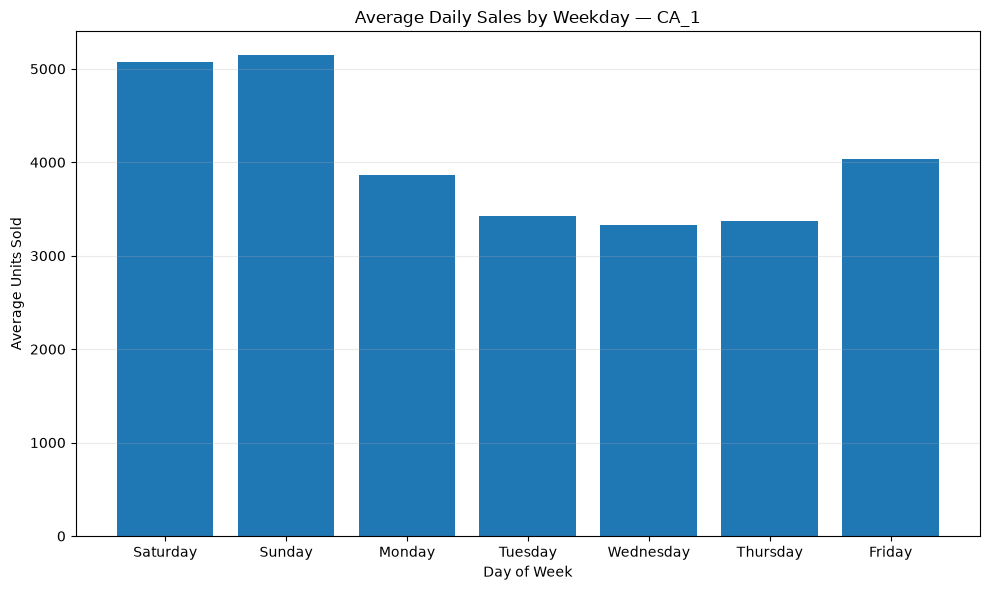

In [16]:
# ---------------------------------------------------------
# Visualize average demand by weekday
# ---------------------------------------------------------
# The weekday summary indicates substantial differences in
# store demand across the seven days of the week.
#
# A bar chart makes the magnitude of these differences easier
# to compare than the summary table alone.

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    weekday_sales["weekday"].astype(str),
    weekday_sales["average_sales"]
)

ax.set_title("Average Daily Sales by Weekday — CA_1")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Units Sold")

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [17]:
# ---------------------------------------------------------
# Quantify the weekday demand range
# ---------------------------------------------------------
# Identifying the highest- and lowest-demand weekdays allows
# us to express the weekly seasonal effect numerically rather
# than relying only on visual interpretation.

highest_weekday = weekday_sales.loc[
    weekday_sales["average_sales"].idxmax()
]

lowest_weekday = weekday_sales.loc[
    weekday_sales["average_sales"].idxmin()
]

weekday_difference_pct = (
    (
        highest_weekday["average_sales"]
        - lowest_weekday["average_sales"]
    )
    / lowest_weekday["average_sales"]
    * 100
)

print(
    "Highest-demand weekday:",
    highest_weekday["weekday"]
)

print(
    "Average sales on highest-demand weekday:",
    f'{highest_weekday["average_sales"]:,.2f}'
)

print(
    "Lowest-demand weekday:",
    lowest_weekday["weekday"]
)

print(
    "Average sales on lowest-demand weekday:",
    f'{lowest_weekday["average_sales"]:,.2f}'
)

print(
    "Difference:",
    f"{weekday_difference_pct:.1f}%"
)

Highest-demand weekday: Sunday
Average sales on highest-demand weekday: 5,144.44
Lowest-demand weekday: Wednesday
Average sales on lowest-demand weekday: 3,329.59
Difference: 54.5%


### Weekly Demand Findings

CA_1 exhibits a strong weekly demand pattern.

Weekend demand is substantially higher than weekday demand. Sunday has the
highest average demand at approximately 5,144 units per day, followed closely
by Saturday at approximately 5,078 units.

Demand declines after the weekend and reaches its lowest average level on
Wednesday at approximately 3,330 units before beginning to recover toward
Friday and the weekend.

Average Sunday demand is approximately 54.5% higher than average Wednesday
demand. Median sales follow a similar pattern, suggesting that the result is
not driven solely by a small number of unusually high-demand days.

The magnitude and consistency of these differences indicate that weekday
information is likely to be an important predictor in the forecasting stage.

## 3. Demand by Product Category

CA_1 sells products across three major categories: Foods, Household, and
Hobbies.

This section examines how total historical demand is distributed across these
categories. Understanding category-level demand concentration helps identify
which parts of the product hierarchy contribute most strongly to overall
store demand.

In [18]:
# ---------------------------------------------------------
# Aggregate historical sales by product category
# ---------------------------------------------------------
# Each row represents one item-day observation. Summing the
# sales target within each category measures the total number
# of units sold by that category across the historical period.

category_sales = (
    df.groupby(
        "cat_id",
        observed=True
    )
    .agg(
        total_sales=("sales", "sum"),
        average_daily_item_sales=("sales", "mean"),
        number_of_products=("item_id", "nunique")
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate each category's share of total store demand
# ---------------------------------------------------------
# The sales share makes category contributions directly
# comparable even though categories contain different numbers
# of products.

category_sales["sales_share_pct"] = (
    category_sales["total_sales"]
    / category_sales["total_sales"].sum()
    * 100
)

category_sales = category_sales.sort_values(
    "total_sales",
    ascending=False
).reset_index(drop=True)

category_sales

,cat_id,total_sales,average_daily_item_sales,number_of_products,sales_share_pct
0,FOODS,5471661,1.961719,1437,69.860671
1,HOUSEHOLD,1468504,0.722608,1047,18.749457
2,HOBBIES,892083,0.813451,565,11.389872


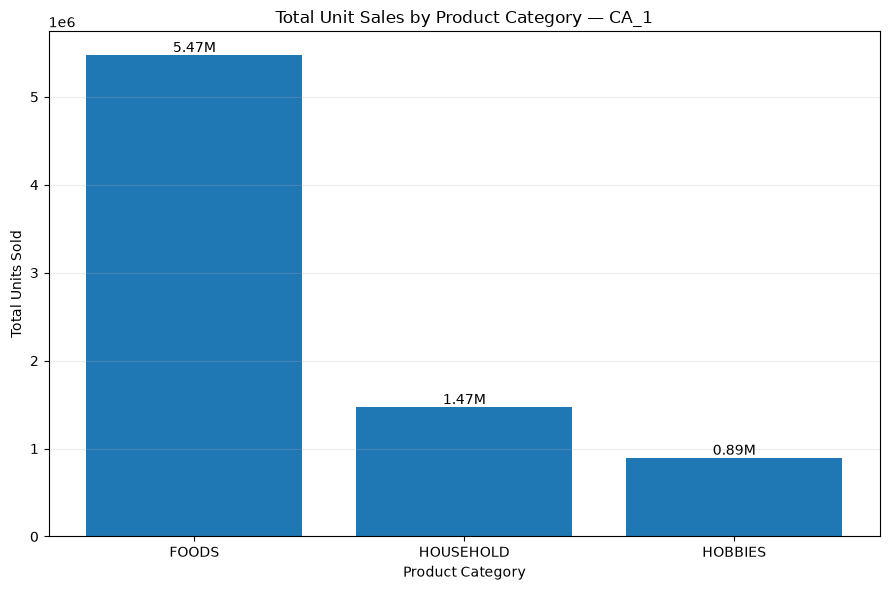

In [19]:
# ---------------------------------------------------------
# Visualize total historical sales by product category
# ---------------------------------------------------------
# Total unit sales show the overall contribution of each
# category to CA_1 demand across the historical period.
#
# The categories are already ordered from highest to lowest
# total demand.

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    category_sales["cat_id"].astype(str),
    category_sales["total_sales"]
)

ax.set_title("Total Unit Sales by Product Category — CA_1")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Units Sold")

# Display the total number of units above each bar so the
# magnitude can be read directly from the visualization.
for bar, value in zip(
    bars,
    category_sales["total_sales"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1_000_000:.2f}M",
        ha="center",
        va="bottom"
    )

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Category Demand Findings

Demand at CA_1 is strongly concentrated in the Foods category. Foods accounts
for approximately 69.9% of all units sold during the historical period,
compared with 18.7% for Household and 11.4% for Hobbies.

Foods also contains the largest product assortment, with 1,437 unique items.
However, assortment size alone does not explain its dominance. The average
item-day sales value for Foods is approximately 1.96 units, substantially
higher than Household (0.72) and Hobbies (0.81).

Therefore, the concentration of store demand in Foods reflects both a larger
number of products and stronger average demand at the item level.

This category imbalance suggests that aggregate store-level demand patterns
may be influenced heavily by Foods. Examining the lower-level department
hierarchy is therefore necessary to determine whether demand is concentrated
further within particular product groups.

In [20]:
# ---------------------------------------------------------
# Aggregate historical demand by department
# ---------------------------------------------------------
# Departments provide a more detailed level of the M5 product
# hierarchy than the three broad product categories.
#
# We calculate the same metrics used in the category analysis
# so that demand concentration can be compared consistently.

department_sales = (
    df.groupby(
        ["cat_id", "dept_id"],
        observed=True
    )
    .agg(
        total_sales=("sales", "sum"),
        average_daily_item_sales=("sales", "mean"),
        number_of_products=("item_id", "nunique")
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate department share of total CA_1 demand
# ---------------------------------------------------------
# This percentage is relative to total store sales, not merely
# the parent category. It therefore shows how much each
# department contributes to overall CA_1 demand.

department_sales["sales_share_pct"] = (
    department_sales["total_sales"]
    / department_sales["total_sales"].sum()
    * 100
)

department_sales = department_sales.sort_values(
    "total_sales",
    ascending=False
).reset_index(drop=True)

department_sales

,cat_id,dept_id,total_sales,average_daily_item_sales,number_of_products,sales_share_pct
0,FOODS,FOODS_3,3993834,2.500142,823,50.992180
1,HOUSEHOLD,HOUSEHOLD_1,1121388,1.085972,532,14.317575
2,FOODS,FOODS_2,900391,1.165528,398,11.495946
3,HOBBIES,HOBBIES_1,835578,1.034828,416,10.668431
4,FOODS,FOODS_1,577436,1.377287,216,7.372545
5,HOUSEHOLD,HOUSEHOLD_2,347116,0.347250,515,4.431882
6,HOBBIES,HOBBIES_2,56505,0.195378,149,0.721440


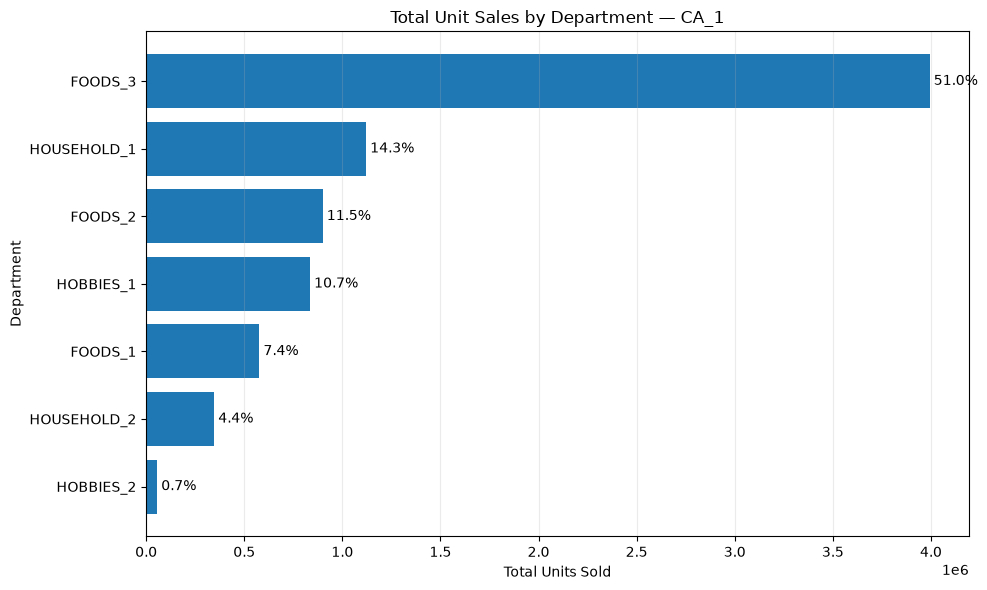

In [21]:
# ---------------------------------------------------------
# Visualize total historical sales by department
# ---------------------------------------------------------
# Department-level demand is highly uneven, so a horizontal
# bar chart makes both the ranking and department labels easy
# to compare.
#
# The DataFrame is sorted in ascending order here so that the
# highest-demand department appears at the top of the chart.

department_plot = department_sales.sort_values(
    "total_sales",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    department_plot["dept_id"].astype(str),
    department_plot["total_sales"]
)

ax.set_title("Total Unit Sales by Department — CA_1")
ax.set_xlabel("Total Units Sold")
ax.set_ylabel("Department")

# Add percentage labels to show each department's contribution
# to total historical CA_1 demand.
for bar, share in zip(
    bars,
    department_plot["sales_share_pct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {share:.1f}%",
        va="center"
    )

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Department Demand Findings

Demand concentration becomes even more pronounced at the department level.

FOODS_3 is the dominant department, accounting for approximately 51.0% of
all historical units sold at CA_1. It contains 823 products and also has the
highest average item-day demand at approximately 2.50 units.

The next-largest departments contribute substantially smaller shares:
HOUSEHOLD_1 accounts for approximately 14.3%, FOODS_2 for 11.5%, and
HOBBIES_1 for 10.7%.

At the lower end of the hierarchy, HOUSEHOLD_2 contributes approximately
4.4% of store demand and HOBBIES_2 contributes less than 1%.

These results show that demand is highly heterogeneous across the product
hierarchy. Aggregate store-level patterns are therefore influenced heavily
by FOODS_3, while lower-volume departments may exhibit substantially
different forecasting characteristics.

## 4. Product-Level Demand and Intermittency

Store- and department-level aggregates can hide substantial differences in
individual product demand.

At the item level, retail demand may contain many zero-sales observations.
However, a zero sale can occur for different reasons. A product may not yet
be available for sale, or it may be available but receive no demand on a
particular day.

This section separates product availability from zero observed demand and
examines the degree of demand intermittency among available products.

In [23]:
# ---------------------------------------------------------
# Separate unavailable observations from observed demand
# ---------------------------------------------------------
# `is_available == 1` indicates that the item has a valid
# selling price for that item-store-week combination.
#
# We therefore distinguish three states:
#
#   1. unavailable:
#      No valid selling price is recorded.
#
#   2. available_zero_sales:
#      The product is available but records zero unit sales.
#
#   3. available_positive_sales:
#      The product is available and records positive sales.
#
# This distinction prevents unavailable periods from being
# incorrectly interpreted as genuine zero-demand observations.

demand_state = np.select(
    [
        df["is_available"].eq(0),
        df["is_available"].eq(1) & df["sales"].eq(0),
        df["is_available"].eq(1) & df["sales"].gt(0),
    ],
    [
        "unavailable",
        "available_zero_sales",
        "available_positive_sales",
    ],
    default="unexpected"
)


# ---------------------------------------------------------
# Count observations in each demand state
# ---------------------------------------------------------

demand_state_summary = (
    pd.Series(
        demand_state,
        name="demand_state"
    )
    .value_counts()
    .rename_axis("demand_state")
    .reset_index(name="observations")
)

demand_state_summary["share_pct"] = (
    demand_state_summary["observations"]
    / len(df)
    * 100
)

demand_state_summary

,demand_state,observations,share_pct
0,available_zero_sales,2643488,44.667782
1,available_positive_sales,2144779,36.240951
2,unavailable,1129842,19.091267


In [24]:
# ---------------------------------------------------------
# Measure zero demand among available observations
# ---------------------------------------------------------
# Unavailable item-days are excluded from this calculation
# because a lack of sales when an item is unavailable should
# not be interpreted as zero customer demand.
#
# The resulting zero-sales rate measures how frequently an
# available product records no unit sales.

available_df = df[
    df["is_available"].eq(1)
]

available_zero_rate = (
    available_df["sales"].eq(0).mean() * 100
)

available_positive_rate = (
    available_df["sales"].gt(0).mean() * 100
)

print(
    "Available item-day observations:",
    f"{len(available_df):,}"
)

print(
    "Zero-sales rate among available observations:",
    f"{available_zero_rate:.2f}%"
)

print(
    "Positive-sales rate among available observations:",
    f"{available_positive_rate:.2f}%"
)

Available item-day observations: 4,788,267
Zero-sales rate among available observations: 55.21%
Positive-sales rate among available observations: 44.79%


In [25]:
# ---------------------------------------------------------
# Calculate demand intermittency for each product
# ---------------------------------------------------------
# Only periods when the product is available are considered.
# This prevents pre-release or otherwise unavailable periods
# from artificially increasing a product's zero-sales rate.
#
# For each item we calculate:
#   - number of available days,
#   - number of zero-sales days while available,
#   - number of positive-sales days,
#   - total units sold.

product_demand = (
    available_df
    .groupby(
        "item_id",
        observed=True
    )
    .agg(
        available_days=("date", "count"),
        zero_sales_days=(
            "sales",
            lambda x: x.eq(0).sum()
        ),
        positive_sales_days=(
            "sales",
            lambda x: x.gt(0).sum()
        ),
        total_sales=("sales", "sum"),
        average_sales=("sales", "mean"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate each product's zero-sales rate
# ---------------------------------------------------------
# A high value indicates intermittent or sparse demand,
# whereas a low value indicates more consistently observed
# positive demand.

product_demand["zero_sales_rate_pct"] = (
    product_demand["zero_sales_days"]
    / product_demand["available_days"]
    * 100
)

product_demand["positive_sales_rate_pct"] = (
    product_demand["positive_sales_days"]
    / product_demand["available_days"]
    * 100
)


# ---------------------------------------------------------
# Summarize the distribution across products
# ---------------------------------------------------------
# Percentiles are more informative than a single average
# because products can have very different demand patterns.

product_demand["zero_sales_rate_pct"].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

count    3049.000000
mean       55.803460
std        22.682387
min         0.309119
10%        23.971995
25%        39.155075
50%        57.959815
75%        74.549201
90%        84.750129
95%        88.876169
99%        93.061842
max        97.196262
Name: zero_sales_rate_pct, dtype: float64

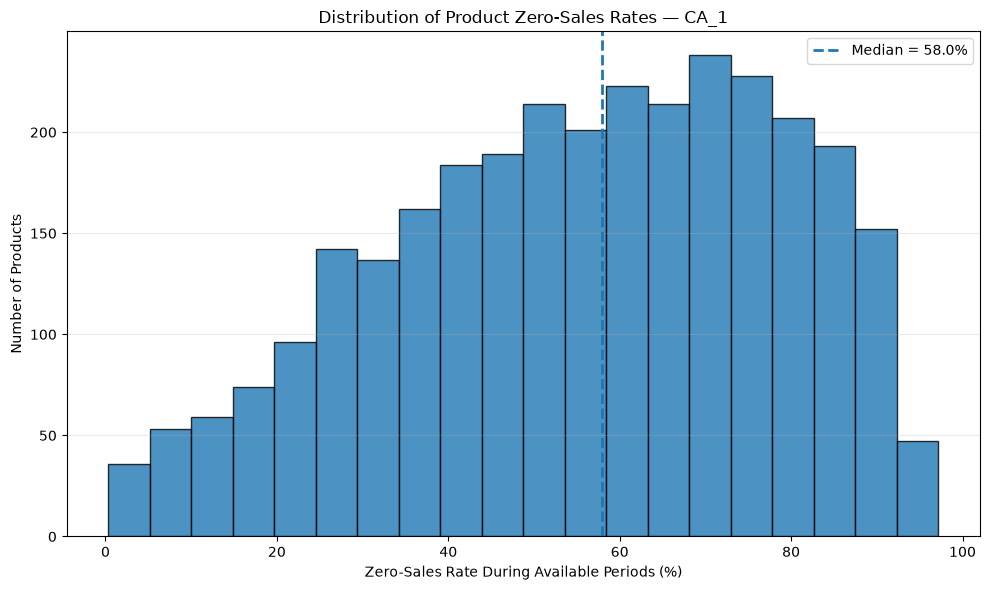

In [26]:
# ---------------------------------------------------------
# Visualize product-level zero-sales rates
# ---------------------------------------------------------
# Each observation in this histogram represents one product.
#
# The x-axis shows the percentage of available days on which
# the product recorded zero sales. Products near 0% have
# frequent demand, while products near 100% have highly
# intermittent demand.

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    product_demand["zero_sales_rate_pct"],
    bins=20,
    edgecolor="black",
    alpha=0.8
)

# Mark the median product to make the central tendency of the
# distribution easier to interpret.
median_zero_rate = (
    product_demand["zero_sales_rate_pct"].median()
)

ax.axvline(
    median_zero_rate,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_zero_rate:.1f}%"
)

ax.set_title(
    "Distribution of Product Zero-Sales Rates — CA_1"
)

ax.set_xlabel(
    "Zero-Sales Rate During Available Periods (%)"
)

ax.set_ylabel("Number of Products")

ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Product Demand Intermittency Findings

Product-level demand at CA_1 is highly zero-heavy.

Across all available item-day observations, approximately 55.2% record zero
unit sales, while 44.8% record positive sales. Unavailable periods are
excluded from this calculation so that pre-release or otherwise unavailable
periods are not incorrectly classified as zero customer demand.

The pattern is widespread across individual products rather than being driven
by only a small group of slow-moving items. The median product records zero
sales on approximately 58.0% of its available days, while 25% of products
have zero-sales rates above approximately 74.5%.

Demand behavior also varies substantially between products. Product-level
zero-sales rates range from approximately 0.3% to 97.2%, indicating that the
assortment contains both frequently purchased products and highly
intermittent products.

This heterogeneity is important for forecasting because models must handle
both frequent-demand and sparse-demand time series. Availability should also
be treated separately from observed zero demand during feature engineering
and model evaluation.

### Demand Intermittency by Product Category

The overall product analysis shows substantial variation in zero-sales rates.
The next step is to determine whether this intermittency differs systematically
across the major product categories.

Only observations where products are available for sale are included, ensuring
that unavailable periods are not interpreted as zero customer demand.

In [27]:
# ---------------------------------------------------------
# Calculate zero-sales behavior by product category
# ---------------------------------------------------------
# Only available observations are included. This allows the
# resulting percentages to represent observed demand behavior
# rather than a mixture of demand and product availability.

category_intermittency = (
    available_df
    .groupby(
        "cat_id",
        observed=True
    )
    .agg(
        available_observations=("sales", "size"),
        zero_sales_observations=(
            "sales",
            lambda x: x.eq(0).sum()
        ),
        positive_sales_observations=(
            "sales",
            lambda x: x.gt(0).sum()
        ),
        average_sales=("sales", "mean"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate zero- and positive-sales rates
# ---------------------------------------------------------
# These two percentages should sum to 100% for each category
# because unavailable observations have already been removed.

category_intermittency["zero_sales_rate_pct"] = (
    category_intermittency["zero_sales_observations"]
    / category_intermittency["available_observations"]
    * 100
)

category_intermittency["positive_sales_rate_pct"] = (
    category_intermittency["positive_sales_observations"]
    / category_intermittency["available_observations"]
    * 100
)


# Order categories from the most to least zero-heavy so that
# differences in demand intermittency are easy to identify.
category_intermittency = (
    category_intermittency
    .sort_values(
        "zero_sales_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

category_intermittency

,cat_id,available_observations,zero_sales_observations,positive_sales_observations,average_sales,zero_sales_rate_pct,positive_sales_rate_pct
0,HOBBIES,888758,588480,300278,1.003741,66.213750,33.786250
1,HOUSEHOLD,1639268,996400,642868,0.895829,60.783228,39.216772
2,FOODS,2260241,1058608,1201633,2.420831,46.836067,53.163933


### Category-Level Intermittency Findings

Demand intermittency differs substantially across the three product categories.

Hobbies has the highest zero-sales rate, with approximately 66.2% of available
item-day observations recording no sales. Household follows at approximately
60.8%.

Foods exhibits substantially more frequent demand. Approximately 46.8% of its
available item-day observations record zero sales, while 53.2% record positive
sales. Foods is therefore the only major category in which positive-sales
observations are more common than zero-sales observations.

These results demonstrate that the forecasting problem differs across the
product hierarchy. Hobbies and Household contain substantially more sparse
demand than Foods, suggesting that category and department information may
help forecasting models distinguish between different demand regimes.

In [28]:
# ---------------------------------------------------------
# Calculate zero-sales behavior by department
# ---------------------------------------------------------
# Department-level analysis determines whether the broad
# category differences are also present within categories.
#
# As before, only periods in which products are available are
# included in the calculation.

department_intermittency = (
    available_df
    .groupby(
        ["cat_id", "dept_id"],
        observed=True
    )
    .agg(
        available_observations=("sales", "size"),
        zero_sales_observations=(
            "sales",
            lambda x: x.eq(0).sum()
        ),
        positive_sales_observations=(
            "sales",
            lambda x: x.gt(0).sum()
        ),
        average_sales=("sales", "mean"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Calculate department-level demand frequencies
# ---------------------------------------------------------

department_intermittency["zero_sales_rate_pct"] = (
    department_intermittency["zero_sales_observations"]
    / department_intermittency["available_observations"]
    * 100
)

department_intermittency["positive_sales_rate_pct"] = (
    department_intermittency["positive_sales_observations"]
    / department_intermittency["available_observations"]
    * 100
)


# Sort from most intermittent to least intermittent.
department_intermittency = (
    department_intermittency
    .sort_values(
        "zero_sales_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

department_intermittency

,cat_id,dept_id,available_observations,zero_sales_observations,positive_sales_observations,average_sales,zero_sales_rate_pct,positive_sales_rate_pct
0,HOBBIES,HOBBIES_2,225327,189933,35394,0.250769,84.292162,15.707838
1,HOUSEHOLD,HOUSEHOLD_2,837355,611702,225653,0.414539,73.051693,26.948307
2,HOBBIES,HOBBIES_1,663431,398547,264884,1.259480,60.073617,39.926383
3,FOODS,FOODS_2,622095,342061,280034,1.447353,54.985332,45.014668
4,FOODS,FOODS_1,357964,186428,171536,1.613112,52.080097,47.919903
5,HOUSEHOLD,HOUSEHOLD_1,801913,384698,417215,1.398391,47.972536,52.027464
6,FOODS,FOODS_3,1280182,530119,750063,3.119739,41.409659,58.590341


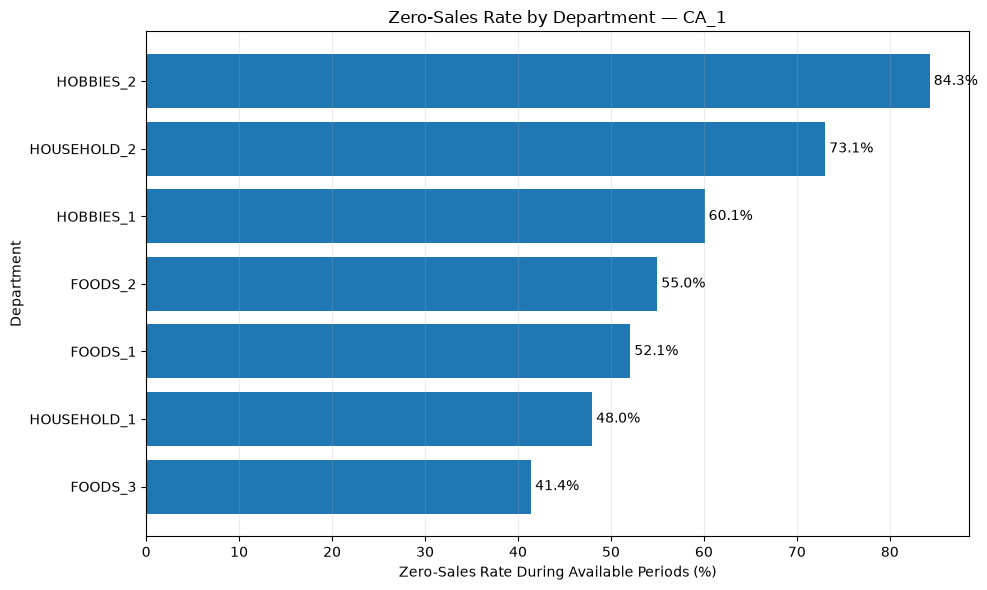

In [29]:
# ---------------------------------------------------------
# Visualize zero-sales rates by department
# ---------------------------------------------------------
# Departments are ordered by zero-sales rate so that the
# difference between frequent-demand and intermittent-demand
# product groups is easy to identify.
#
# Only available item-day observations are represented in
# these percentages.

department_intermittency_plot = (
    department_intermittency
    .sort_values(
        "zero_sales_rate_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    department_intermittency_plot["dept_id"].astype(str),
    department_intermittency_plot["zero_sales_rate_pct"]
)

ax.set_title(
    "Zero-Sales Rate by Department — CA_1"
)

ax.set_xlabel(
    "Zero-Sales Rate During Available Periods (%)"
)

ax.set_ylabel("Department")


# Add percentage labels so the magnitude of intermittency can
# be read directly from the chart.
for bar, value in zip(
    bars,
    department_intermittency_plot["zero_sales_rate_pct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f}%",
        va="center"
    )

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Department-Level Intermittency Findings

Demand intermittency varies substantially not only between categories but also
between departments within the same category.

HOBBIES_2 is the most intermittent department, with approximately 84.3% of
available item-day observations recording zero sales. HOUSEHOLD_2 also
exhibits highly sparse demand, with a zero-sales rate of approximately 73.1%.

In contrast, FOODS_3 has the lowest zero-sales rate at approximately 41.4%,
followed by HOUSEHOLD_1 at approximately 48.0%.

Substantial within-category differences are also present. For example,
HOBBIES_1 has a zero-sales rate of approximately 60.1%, compared with 84.3%
for HOBBIES_2. Similarly, HOUSEHOLD_1 records approximately 48.0% zero-sales
observations compared with 73.1% for HOUSEHOLD_2.

FOODS_3 is particularly important because it combines relatively frequent
product demand with the largest contribution to total store sales. Earlier
analysis showed that this department accounts for approximately 51% of all
historical units sold at CA_1.

These findings indicate that department-level information captures meaningful
differences in demand behavior that are hidden by broader category-level
aggregates.

## 5. Calendar Event Effects

Retail demand may change around holidays and other calendar events.

The M5 calendar identifies several types of events, including national,
cultural, religious, and sporting events. Christmas has already been shown
to produce a distinctive zero-sales pattern at CA_1.

This section examines whether other calendar events are associated with
systematic changes in store-level demand.

In [30]:
# ---------------------------------------------------------
# Create one calendar record per historical date
# ---------------------------------------------------------
# The analytical dataset contains thousands of product rows
# for each date. Event information is identical across those
# product rows, so we first reduce it to one record per day.
#
# Both event slots are retained because the M5 calendar can
# record up to two events on the same date.

daily_events = (
    df[
        [
            "date",
            "event_name_1",
            "event_type_1",
            "event_name_2",
            "event_type_2",
        ]
    ]
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Summarize event coverage
# ---------------------------------------------------------
# These counts tell us how frequently events occur and whether
# the second event field contains enough observations to
# require explicit treatment later.

event_1_days = daily_events["event_name_1"].notna().sum()
event_2_days = daily_events["event_name_2"].notna().sum()

print(
    "Historical days:",
    f"{len(daily_events):,}"
)

print(
    "Days with a primary event:",
    f"{event_1_days:,}"
)

print(
    "Days with a secondary event:",
    f"{event_2_days:,}"
)

print(
    "Unique primary events:",
    daily_events["event_name_1"].nunique()
)

print(
    "Unique primary event types:",
    daily_events["event_type_1"].nunique()
)

Historical days: 1,941
Days with a primary event: 158
Days with a secondary event: 4
Unique primary events: 30
Unique primary event types: 4


In [31]:
# ---------------------------------------------------------
# Count primary event days by event type
# ---------------------------------------------------------
# This shows how the event calendar is distributed across
# broad event classes before we compare their sales patterns.

event_type_counts = (
    daily_events["event_type_1"]
    .value_counts(dropna=False)
    .rename_axis("event_type")
    .reset_index(name="number_of_days")
)

event_type_counts

,event_type,number_of_days
0,NaN,1783
1,Religious,54
2,National,51
3,Cultural,37
4,Sporting,16


In [32]:
# ---------------------------------------------------------
# Combine daily sales with primary event information
# ---------------------------------------------------------
# Store-level sales contain one row per date, while
# daily_events contains the corresponding event information.
#
# A one-to-one validation ensures that each date appears only
# once in both datasets.

daily_event_sales = daily_sales.merge(
    daily_events[
        [
            "date",
            "event_name_1",
            "event_type_1",
        ]
    ],
    on="date",
    how="left",
    validate="one_to_one"
)


# ---------------------------------------------------------
# Create a simple event-day indicator
# ---------------------------------------------------------
# A day is classified as an event day whenever the primary
# event field contains an event name.

daily_event_sales["is_event_day"] = (
    daily_event_sales["event_name_1"]
    .notna()
)


# ---------------------------------------------------------
# Compare event and non-event demand
# ---------------------------------------------------------
# Both mean and median are reported because unusual holidays
# such as Christmas can strongly affect average demand.

event_vs_non_event = (
    daily_event_sales
    .groupby(
        "is_event_day",
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        minimum_sales=("total_sales", "min"),
        maximum_sales=("total_sales", "max"),
    )
    .reset_index()
)

event_vs_non_event

,is_event_day,number_of_days,average_sales,median_sales,minimum_sales,maximum_sales
0,False,1783,4054.347729,3921.0,2009,6948
1,True,158,3818.645570,3862.5,0,6397


In [33]:
# ---------------------------------------------------------
# Summarize demand by primary event type
# ---------------------------------------------------------
# Non-event days are excluded here because the objective is
# to compare demand across the four broad event classes.
#
# Sample size is retained because an average based on only a
# few event days should be interpreted more cautiously.

event_type_sales = (
    daily_event_sales[
        daily_event_sales["event_type_1"].notna()
    ]
    .groupby(
        "event_type_1",
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        minimum_sales=("total_sales", "min"),
        maximum_sales=("total_sales", "max"),
    )
    .reset_index()
    .sort_values(
        "average_sales",
        ascending=False
    )
    .reset_index(drop=True)
)

event_type_sales

,event_type_1,number_of_days,average_sales,median_sales,minimum_sales,maximum_sales
0,Sporting,16,4061.437500,3831.5,2156,5462
1,Religious,54,3986.574074,3797.5,2085,6397
2,Cultural,37,3949.675676,4184.0,2319,5214
3,National,51,3469.607843,3858.0,0,5838


In [41]:
# ---------------------------------------------------------
# Rebuild the daily event dataset cleanly
# ---------------------------------------------------------
# `daily_event_sales` may already contain weekday columns from
# previous exploratory steps. Rebuilding it from the original
# daily-level tables avoids duplicate-column merge errors and
# keeps the analysis reproducible.

daily_event_sales = (
    daily_sales[
        [
            "date",
            "total_sales",
        ]
    ]
    .merge(
        daily_events[
            [
                "date",
                "event_name_1",
                "event_type_1",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one"
    )
    .merge(
        daily_calendar[
            [
                "date",
                "weekday",
                "wday",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one"
    )
)


# ---------------------------------------------------------
# Recreate the event-day indicator
# ---------------------------------------------------------
# A date is classified as an event day when the primary event
# field contains an event name.

daily_event_sales["is_event_day"] = (
    daily_event_sales["event_name_1"].notna()
)


print(daily_event_sales.columns.tolist())
print("Rows:", len(daily_event_sales))

['date', 'total_sales', 'event_name_1', 'event_type_1', 'weekday', 'wday', 'is_event_day']
Rows: 1941


In [42]:
# ---------------------------------------------------------
# Calculate the normal demand level for each weekday
# ---------------------------------------------------------
# CA_1 has a strong weekly pattern, so this baseline lets us
# compare an event day against the normal sales level for the
# weekday on which it occurs.

weekday_baseline = (
    daily_event_sales
    .groupby(
        "wday",
        observed=True
    )["total_sales"]
    .mean()
    .rename("weekday_average_sales")
    .reset_index()
)


# ---------------------------------------------------------
# Attach weekday baseline and calculate demand deviation
# ---------------------------------------------------------

daily_event_sales = daily_event_sales.merge(
    weekday_baseline,
    on="wday",
    how="left",
    validate="many_to_one"
)

daily_event_sales["weekday_deviation_pct"] = (
    (
        daily_event_sales["total_sales"]
        - daily_event_sales["weekday_average_sales"]
    )
    / daily_event_sales["weekday_average_sales"]
    * 100
)

In [43]:
# ---------------------------------------------------------
# Compare event types after adjusting for weekday seasonality
# ---------------------------------------------------------

event_type_adjusted = (
    daily_event_sales[
        daily_event_sales["event_type_1"].notna()
    ]
    .groupby(
        "event_type_1",
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "mean"
        ),
        median_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "median"
        ),
    )
    .reset_index()
    .sort_values(
        "average_weekday_deviation_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

event_type_adjusted

,event_type_1,number_of_days,average_weekday_deviation_pct,median_weekday_deviation_pct
0,Religious,54,0.213903,1.889107
1,Sporting,16,-3.513556,-2.069076
2,National,51,-9.304259,-3.736084
3,Cultural,37,-11.410490,-9.241865


In [44]:
# ---------------------------------------------------------
# Measure weekday-adjusted demand by individual event
# ---------------------------------------------------------
# Broad event types can hide substantial differences between
# specific holidays or occasions.
#
# For example, National events include Christmas, which we
# already know has an exceptional zero-sales pattern.
#
# We therefore calculate the average and median deviation from
# normal weekday demand for each individual primary event.

individual_event_effects = (
    daily_event_sales[
        daily_event_sales["event_name_1"].notna()
    ]
    .groupby(
        [
            "event_type_1",
            "event_name_1",
        ],
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_sales=("total_sales", "mean"),
        average_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "mean"
        ),
        median_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "median"
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Sort events from strongest positive to strongest negative
# weekday-adjusted demand association.
# ---------------------------------------------------------

individual_event_effects = (
    individual_event_effects
    .sort_values(
        "average_weekday_deviation_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

individual_event_effects

,event_type_1,event_name_1,number_of_days,average_sales,average_weekday_deviation_pct,median_weekday_deviation_pct
0,National,LaborDay,5,5092.000000,31.732292,38.251644
1,National,ColumbusDay,5,4199.800000,8.650684,7.957356
2,National,MemorialDay,5,4121.600000,6.627615,13.571242
3,Religious,Ramadan starts,5,4158.600000,5.749477,11.303345
4,National,VeteransDay,5,4119.000000,5.279512,11.184912
5,Religious,OrthodoxChristmas,5,3942.400000,4.722708,1.934520
6,Religious,Eid al-Fitr,5,4283.400000,4.555769,11.381052
7,National,MartinLutherKingDay,5,4039.000000,4.490717,3.973308
8,National,PresidentsDay,6,3957.333333,2.377964,2.058895
9,Cultural,Cinco De Mayo,5,3862.000000,2.025063,13.390149


### Event Demand Findings

Calendar events are associated with substantial variation in CA_1 demand, but
the effects differ considerably between individual events.

After adjusting each event day relative to the normal demand level for its
weekday, Religious events show little overall deviation, while Sporting,
National, and Cultural events exhibit lower average demand. However, these
broad event-type averages conceal substantial differences between individual
events.

Among the strongest positive associations, Labor Day records average demand
approximately 31.7% above its normal weekday level. Columbus Day and Memorial
Day are also associated with above-baseline demand.

Several major holidays show substantial negative deviations. New Year's Day
averages approximately 21.6% below its weekday baseline, Thanksgiving
approximately 34.7% below, and Christmas 100% below because CA_1 records zero
sales on Christmas Day throughout the observed period.

Individual events within the same event type can therefore exhibit very
different demand patterns. Event names may consequently provide more useful
forecasting information than broad event-type labels alone.

These results are descriptive rather than causal. Most individual events occur
only four to six times in the historical dataset, so estimated event-specific
patterns are based on relatively small samples.

## 6. SNAP-Related Demand Patterns

The M5 calendar identifies dates associated with SNAP benefits for California.

This section compares CA_1 demand between SNAP and non-SNAP days. Because the
store exhibits strong weekday seasonality, both raw sales levels and deviations
from normal weekday demand are examined.

In [45]:
# ---------------------------------------------------------
# Create one SNAP indicator per historical date
# ---------------------------------------------------------
# The processed dataset repeats the SNAP indicator across all
# products sold on the same date. We therefore extract one
# unique calendar observation per day.

daily_snap = (
    df[
        [
            "date",
            "snap_CA",
        ]
    ]
    .drop_duplicates(subset="date")
    .copy()
)


# ---------------------------------------------------------
# Add SNAP information to the weekday-adjusted daily dataset
# ---------------------------------------------------------
# `daily_event_sales` already contains total daily demand and
# the deviation from the normal sales level for each weekday.

daily_snap_sales = daily_event_sales.merge(
    daily_snap,
    on="date",
    how="left",
    validate="one_to_one"
)


# ---------------------------------------------------------
# Compare SNAP and non-SNAP days
# ---------------------------------------------------------
# Average and median raw sales show the observed demand level.
#
# Weekday-adjusted deviations help determine whether SNAP days
# tend to have unusually high or low demand after accounting
# for CA_1's strong weekly seasonality.

snap_summary = (
    daily_snap_sales
    .groupby(
        "snap_CA",
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        average_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "mean"
        ),
        median_weekday_deviation_pct=(
            "weekday_deviation_pct",
            "median"
        ),
    )
    .reset_index()
)

snap_summary

,snap_CA,number_of_days,average_sales,median_sales,average_weekday_deviation_pct,median_weekday_deviation_pct
0,0,1301,3908.552652,3797.0,-3.287230,-0.341730
1,1,640,4292.532812,4109.5,6.682323,7.914267


### SNAP Demand Findings

CA_1 exhibits a clear difference in demand between SNAP and non-SNAP days.

Average daily sales are approximately 4,293 units on SNAP days compared with
approximately 3,909 units on non-SNAP days, representing a raw difference of
about 9.8%.

The difference remains after accounting for CA_1's strong weekday demand
pattern. SNAP days average approximately 6.7% above the normal demand level
for their corresponding weekday, with a median deviation of approximately
7.9%. In contrast, non-SNAP days average approximately 3.3% below their
weekday baseline.

The pattern is supported by a relatively large number of observations, with
640 SNAP days and 1,301 non-SNAP days in the historical period.

These results indicate that the California SNAP calendar variable contains
potentially useful information for forecasting demand at CA_1. The relationship
should nevertheless be interpreted as an association rather than evidence that
SNAP status directly causes the observed change in sales.

In [46]:
# ---------------------------------------------------------
# Examine price observations for available products
# ---------------------------------------------------------
# Missing prices correspond to unavailable product periods,
# as established during data preparation. We therefore use
# only observations where the product is available when
# describing the distribution of selling prices.

available_prices = df.loc[
    df["is_available"].eq(1),
    "sell_price"
]

price_summary = available_prices.describe(
    percentiles=[
        0.01,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.99,
    ]
)

price_summary

count    4.788267e+06
mean     4.412670e+00
std      3.397716e+00
min      1.000000e-02
1%       4.800000e-01
10%      1.250000e+00
25%      2.220000e+00
50%      3.470000e+00
75%      5.770000e+00
90%      8.640000e+00
99%      1.794000e+01
max      3.098000e+01
Name: sell_price, dtype: float64

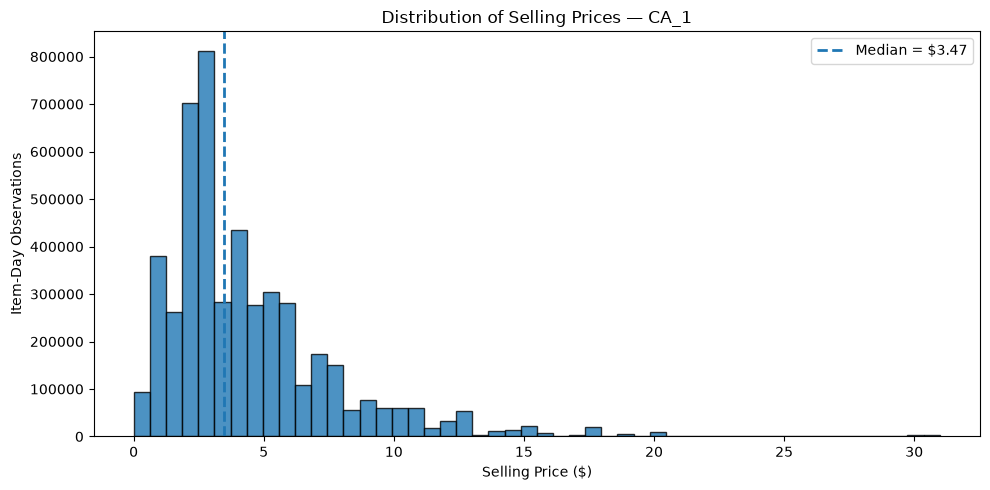

In [47]:
# ---------------------------------------------------------
# Visualize the distribution of observed selling prices
# ---------------------------------------------------------
# Only available product periods are included because missing
# prices represent periods when a product was unavailable.
#
# We retain the complete observed price range rather than
# removing high or low values at this stage. Unusual prices
# should be investigated before being treated as outliers.

plt.figure(figsize=(10, 5))

plt.hist(
    available_prices,
    bins=50,
    edgecolor="black",
    alpha=0.8
)

# Show the median to make the right-skew easier to interpret.
plt.axvline(
    available_prices.median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = ${available_prices.median():.2f}"
)

plt.title("Distribution of Selling Prices — CA_1")
plt.xlabel("Selling Price ($)")
plt.ylabel("Item-Day Observations")
plt.legend()
plt.tight_layout()
plt.show()

### Price Distribution Findings

Selling prices at CA_1 exhibit a right-skewed distribution.

Across available item-day observations, the median selling price is
approximately $3.47, while the mean is higher at approximately $4.41.
Approximately 75% of observations have prices at or below $5.77 and 90%
are at or below $8.64. The upper tail extends to a maximum observed price
of $30.98.

The difference between the mean and median, together with the upper
percentiles, indicates that most observations correspond to relatively
low-priced products while a smaller proportion of observations represent
substantially higher-priced items.

These values describe item-day price observations rather than unique
products, meaning that products maintaining the same price across multiple
days contribute repeated observations to the distribution.

Extreme price observations are retained at this stage because unusual prices
may represent legitimate promotions, markdowns, or product-specific pricing
rather than data errors.

In [48]:
# ---------------------------------------------------------
# Create a unique item-week price table
# ---------------------------------------------------------
# M5 selling prices are recorded at the weekly level, while
# the modeling dataset contains one row per item per day.
#
# We therefore remove repeated daily observations before
# analyzing price changes.

weekly_prices = (
    df.loc[
        df["sell_price"].notna(),
        [
            "item_id",
            "wm_yr_wk",
            "sell_price",
        ]
    ]
    .drop_duplicates(
        subset=[
            "item_id",
            "wm_yr_wk",
        ]
    )
    .sort_values(
        [
            "item_id",
            "wm_yr_wk",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Calculate the previous observed weekly price
# ---------------------------------------------------------
# The shift is performed separately for every product so that
# price comparisons never cross product boundaries.

weekly_prices["previous_price"] = (
    weekly_prices
    .groupby(
        "item_id",
        observed=True
    )["sell_price"]
    .shift(1)
)


# ---------------------------------------------------------
# Identify observed price changes
# ---------------------------------------------------------
# The first observed week for each product has no previous
# price and therefore cannot be classified as a change.
#
# np.isclose is used instead of direct floating-point equality
# to avoid classifying tiny numerical representation
# differences as genuine price changes.

weekly_prices["price_changed"] = np.where(
    weekly_prices["previous_price"].notna(),
    ~np.isclose(
        weekly_prices["sell_price"],
        weekly_prices["previous_price"]
    ),
    False
)


# ---------------------------------------------------------
# Summarize price-change frequency
# ---------------------------------------------------------

comparable_weeks = weekly_prices["previous_price"].notna()

print(
    "Unique item-week price observations:",
    f"{len(weekly_prices):,}"
)

print(
    "Comparable item-week observations:",
    f"{comparable_weeks.sum():,}"
)

print(
    "Observed price changes:",
    f"{weekly_prices.loc[comparable_weeks, 'price_changed'].sum():,}"
)

print(
    "Price-change rate:",
    f"{weekly_prices.loc[comparable_weeks, 'price_changed'].mean() * 100:.2f}%"
)

Unique item-week price observations: 686,216
Comparable item-week observations: 683,167
Observed price changes: 6,320
Price-change rate: 0.93%


In [49]:
# ---------------------------------------------------------
# Calculate absolute and percentage price changes
# ---------------------------------------------------------
# Price-change calculations are performed only when a previous
# observed weekly price exists.
#
# Percentage change is especially useful because a $1 change
# has very different economic meaning for a $2 product than
# for a $20 product.

weekly_prices["price_change"] = (
    weekly_prices["sell_price"]
    - weekly_prices["previous_price"]
)

weekly_prices["price_change_pct"] = (
    weekly_prices["price_change"]
    / weekly_prices["previous_price"]
    * 100
)


# ---------------------------------------------------------
# Keep only weeks where an actual price change occurred
# ---------------------------------------------------------
# Stable-price weeks are excluded so that their large number
# does not dominate the distribution of change magnitudes.

changed_prices = weekly_prices.loc[
    weekly_prices["price_changed"]
].copy()


# ---------------------------------------------------------
# Classify each change by direction
# ---------------------------------------------------------

changed_prices["change_direction"] = np.where(
    changed_prices["price_change"] > 0,
    "Increase",
    "Decrease"
)


# ---------------------------------------------------------
# Summarize increases and decreases
# ---------------------------------------------------------
# Median percentage change is included because a small number
# of very large markdowns or increases could distort the mean.

price_change_direction = (
    changed_prices
    .groupby(
        "change_direction",
        observed=True
    )
    .agg(
        number_of_changes=("price_change", "count"),
        average_change_pct=("price_change_pct", "mean"),
        median_change_pct=("price_change_pct", "median"),
        minimum_change_pct=("price_change_pct", "min"),
        maximum_change_pct=("price_change_pct", "max"),
    )
    .reset_index()
)

price_change_direction

,change_direction,number_of_changes,average_change_pct,median_change_pct,minimum_change_pct,maximum_change_pct
0,Decrease,2558,-10.591928,-7.716049,-99.595142,-0.062578
1,Increase,3762,20.736786,7.194245,0.091158,24600.000000


In [50]:
# ---------------------------------------------------------
# Inspect the largest percentage price increases
# ---------------------------------------------------------
# Extremely large percentage changes can occur when the
# previous price is very close to zero.
#
# We inspect the underlying prices before deciding whether
# these observations represent valid promotions/markdowns,
# data anomalies, or values requiring special treatment.

largest_price_increases = (
    changed_prices[
        changed_prices["price_change"] > 0
    ]
    .sort_values(
        "price_change_pct",
        ascending=False
    )
    [
        [
            "item_id",
            "wm_yr_wk",
            "previous_price",
            "sell_price",
            "price_change",
            "price_change_pct",
        ]
    ]
    .head(15)
)

largest_price_increases

,item_id,wm_yr_wk,previous_price,sell_price,price_change,price_change_pct
545654,HOUSEHOLD_1_443,11443,0.01,2.47,2.46,24600.000000
435222,HOBBIES_2_075,11509,0.05,2.88,2.83,5660.000000
487215,HOUSEHOLD_1_165,11527,2.00,17.97,15.97,798.500000
681793,HOUSEHOLD_2_497,11439,1.00,6.48,5.48,548.000000
555638,HOUSEHOLD_1_491,11450,1.00,6.42,5.42,542.000000
468144,HOUSEHOLD_1_077,11451,1.00,6.42,5.42,542.000000
492934,HOUSEHOLD_1_189,11448,1.00,5.88,4.88,488.000000
398136,HOBBIES_1_333,11333,0.97,4.97,4.00,412.371134
670269,HOUSEHOLD_2_448,11524,0.99,4.97,3.98,402.020202
540483,HOUSEHOLD_1_419,11439,2.00,8.94,6.94,347.000000


In [51]:
# ---------------------------------------------------------
# Inspect the largest percentage price decreases
# ---------------------------------------------------------
# Large negative changes may represent strong promotions,
# clearance pricing, or unusual observations.
#
# Looking at the actual before-and-after prices helps us
# distinguish meaningful markdowns from potential anomalies.

largest_price_decreases = (
    changed_prices[
        changed_prices["price_change"] < 0
    ]
    .sort_values(
        "price_change_pct",
        ascending=True
    )
    [
        [
            "item_id",
            "wm_yr_wk",
            "previous_price",
            "sell_price",
            "price_change",
            "price_change_pct",
        ]
    ]
    .head(15)
)

largest_price_decreases

,item_id,wm_yr_wk,previous_price,sell_price,price_change,price_change_pct
545653,HOUSEHOLD_1_443,11442,2.47,0.01,-2.46,-99.595142
435221,HOBBIES_2_075,11508,2.88,0.05,-2.83,-98.263889
487214,HOUSEHOLD_1_165,11526,17.97,2.00,-15.97,-88.870339
681792,HOUSEHOLD_2_497,11438,6.48,1.00,-5.48,-84.567901
468143,HOUSEHOLD_1_077,11450,6.42,1.00,-5.42,-84.423676
555637,HOUSEHOLD_1_491,11449,6.42,1.00,-5.42,-84.423676
492928,HOUSEHOLD_1_189,11442,5.48,1.00,-4.48,-81.751825
398135,HOBBIES_1_333,11332,4.97,0.97,-4.00,-80.482897
670268,HOUSEHOLD_2_448,11523,4.97,0.99,-3.98,-80.080483
540482,HOUSEHOLD_1_419,11438,8.94,2.00,-6.94,-77.628635


### Price Change Findings

Selling prices at CA_1 are generally stable from week to week. Among
approximately 683,000 comparable item-week observations, only about 0.93%
record a change from the previous observed price.

Among weeks with a price change, decreases have a median magnitude of
approximately 7.7%, while increases have a median magnitude of approximately
7.2%. However, the percentage-change distribution contains extreme positive
values.

Inspection of the largest changes shows that these extreme values are
primarily associated with very deep temporary price reductions followed by a
return toward the previous price level. For example, one product falls from
$2.47 to $0.01 and subsequently returns from $0.01 to $2.47. The markdown is
approximately -99.6%, while the mathematically corresponding recovery produces
a percentage increase of 24,600%.

These observations are therefore not automatically treated as data errors.
Instead, they demonstrate a limitation of conventional percentage change when
the previous price approaches zero.

For later feature engineering, more robust price representations should be
considered, such as absolute price changes, price relative to a product's
reference price, discount depth, or log-based price changes.

In [52]:
# ---------------------------------------------------------
# Calculate a product-specific reference price
# ---------------------------------------------------------
# Absolute prices are not directly comparable across products.
# A $5 price may be normal for one product but represent a
# substantial discount for another.
#
# The median observed price provides a robust product-specific
# reference level and is less sensitive to temporary extreme
# markdowns than the mean.

product_reference_price = (
    weekly_prices
    .groupby(
        "item_id",
        observed=True
    )["sell_price"]
    .median()
    .rename("reference_price")
    .reset_index()
)


# ---------------------------------------------------------
# Attach the reference price to each item-week observation
# ---------------------------------------------------------

weekly_prices = weekly_prices.merge(
    product_reference_price,
    on="item_id",
    how="left",
    validate="many_to_one"
)


# ---------------------------------------------------------
# Express current price relative to the product's normal price
# ---------------------------------------------------------
# A value of:
#
#   1.00 -> price equals the product's median price
#   0.80 -> price is 20% below its median price
#   1.20 -> price is 20% above its median price
#
# This representation is much more comparable across products
# than raw selling price.

weekly_prices["price_relative_to_median"] = (
    weekly_prices["sell_price"]
    / weekly_prices["reference_price"]
)


# ---------------------------------------------------------
# Summarize the relative-price distribution
# ---------------------------------------------------------

weekly_prices["price_relative_to_median"].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

count    686216.000000
mean          0.999864
std           0.052614
min           0.004049
1%            0.831650
5%            0.922840
10%           0.968519
25%           1.000000
50%           1.000000
75%           1.000000
90%           1.032000
95%           1.079268
99%           1.155405
max           2.880000
Name: price_relative_to_median, dtype: float64

In [53]:
# ---------------------------------------------------------
# Create product-relative price regimes
# ---------------------------------------------------------
# Price levels are classified relative to each product's own
# median price rather than using absolute dollar thresholds.
#
# The bands distinguish meaningful discounts/premiums while
# retaining a narrow range around the typical product price.

weekly_prices["price_regime"] = pd.cut(
    weekly_prices["price_relative_to_median"],
    bins=[
        -np.inf,
        0.90,
        0.98,
        1.02,
        1.10,
        np.inf,
    ],
    labels=[
        "Strong discount",
        "Moderate discount",
        "Typical price",
        "Moderate premium",
        "Strong premium",
    ],
    right=False
)


# ---------------------------------------------------------
# Inspect how frequently each price regime occurs
# ---------------------------------------------------------
# Sample size matters because extreme discount and premium
# regimes may contain substantially fewer observations than
# the typical-price regime.

price_regime_counts = (
    weekly_prices["price_regime"]
    .value_counts(sort=False)
    .rename_axis("price_regime")
    .reset_index(name="item_weeks")
)

price_regime_counts["share_pct"] = (
    price_regime_counts["item_weeks"]
    / price_regime_counts["item_weeks"].sum()
    * 100
)

price_regime_counts

,price_regime,item_weeks,share_pct
0,Strong discount,23886,3.480828
1,Moderate discount,53369,7.777289
2,Typical price,532195,77.555026
3,Moderate premium,52817,7.696848
4,Strong premium,23949,3.490009


In [54]:
# ---------------------------------------------------------
# Aggregate daily demand to the item-week level
# ---------------------------------------------------------
# Selling prices in the M5 dataset are defined weekly, so
# demand should be aggregated to the same temporal grain
# before examining the price-demand relationship.
#
# We use only available observations because unavailable
# product-days should not be interpreted as zero customer
# demand.

weekly_demand = (
    df.loc[
        df["is_available"].eq(1)
    ]
    .groupby(
        [
            "item_id",
            "wm_yr_wk",
        ],
        observed=True
    )
    .agg(
        weekly_sales=("sales", "sum"),
        available_days=("date", "nunique"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Check the resulting analytical grain
# ---------------------------------------------------------
# Most item-week observations should contain seven available
# days, although partial weeks or availability boundaries may
# contain fewer.

print(
    "Item-week demand observations:",
    f"{len(weekly_demand):,}"
)

print(
    "\nAvailable days per item-week:"
)

print(
    weekly_demand["available_days"]
    .value_counts()
    .sort_index()
)

Item-week demand observations: 686,216

Available days per item-week:
available_days
2      3049
7    683167
Name: count, dtype: int64


In [55]:
# ---------------------------------------------------------
# Combine weekly demand with weekly price information
# ---------------------------------------------------------
# Both tables now have exactly one observation per
# item × week, allowing a one-to-one validated merge.

price_demand = weekly_demand.merge(
    weekly_prices[
        [
            "item_id",
            "wm_yr_wk",
            "sell_price",
            "reference_price",
            "price_relative_to_median",
            "price_regime",
        ]
    ],
    on=[
        "item_id",
        "wm_yr_wk",
    ],
    how="inner",
    validate="one_to_one"
)


# ---------------------------------------------------------
# Normalize weekly demand for partial weeks
# ---------------------------------------------------------
# Almost all observations contain seven available days, but
# one boundary week contains only two days per product.
#
# Using average daily sales makes these observations directly
# comparable with complete weeks.

price_demand["average_daily_sales"] = (
    price_demand["weekly_sales"]
    / price_demand["available_days"]
)


# ---------------------------------------------------------
# Calculate each product's typical demand level
# ---------------------------------------------------------
# Products differ greatly in their natural sales volumes.
# Comparing raw demand across price regimes could therefore
# confuse product popularity with a price relationship.
#
# The median daily demand for each product provides a robust
# within-product reference level.

product_demand_baseline = (
    price_demand
    .groupby(
        "item_id",
        observed=True
    )["average_daily_sales"]
    .median()
    .rename("product_median_daily_sales")
    .reset_index()
)


# ---------------------------------------------------------
# Attach the product-specific demand baseline
# ---------------------------------------------------------

price_demand = price_demand.merge(
    product_demand_baseline,
    on="item_id",
    how="left",
    validate="many_to_one"
)


# ---------------------------------------------------------
# Identify products with a usable normalization baseline
# ---------------------------------------------------------
# Some highly intermittent products may have a median demand
# of zero. Dividing by zero would make a relative-demand
# measure undefined, so we explicitly identify those products
# before performing the normalization.

zero_baseline_products = (
    product_demand_baseline[
        product_demand_baseline["product_median_daily_sales"].eq(0)
    ]
)

print(
    "Price-demand observations:",
    f"{len(price_demand):,}"
)

print(
    "Products with zero median daily demand:",
    f"{len(zero_baseline_products):,}"
)

print(
    "Share of products with zero median daily demand:",
    f"{len(zero_baseline_products) / len(product_demand_baseline) * 100:.2f}%"
)

Price-demand observations: 686,216
Products with zero median daily demand: 217
Share of products with zero median daily demand: 7.12%


In [56]:
# ---------------------------------------------------------
# Calculate each product's mean daily demand
# ---------------------------------------------------------
# The median baseline is zero for some highly intermittent
# products. Using the mean allows those products to remain in
# the analysis as long as they recorded at least some sales
# during the historical period.
#
# This baseline is used only for descriptive normalization;
# it is not being proposed as a forecasting feature.

product_mean_demand = (
    price_demand
    .groupby(
        "item_id",
        observed=True
    )["average_daily_sales"]
    .mean()
    .rename("product_mean_daily_sales")
    .reset_index()
)


# ---------------------------------------------------------
# Attach the product-specific mean demand baseline
# ---------------------------------------------------------

price_demand = price_demand.merge(
    product_mean_demand,
    on="item_id",
    how="left",
    validate="many_to_one"
)


# ---------------------------------------------------------
# Check whether any products still have a zero baseline
# ---------------------------------------------------------
# A zero mean would indicate a product that never recorded a
# sale during any available week. Such products cannot support
# ratio-based demand normalization.

zero_mean_products = (
    product_mean_demand[
        product_mean_demand["product_mean_daily_sales"].eq(0)
    ]
)

print(
    "Products with zero mean daily demand:",
    f"{len(zero_mean_products):,}"
)

print(
    "Share of products with zero mean daily demand:",
    f"{len(zero_mean_products) / len(product_mean_demand) * 100:.2f}%"
)


# ---------------------------------------------------------
# Create within-product relative demand
# ---------------------------------------------------------
# A value of:
#
#   1.00 -> demand equals that product's historical mean
#   1.20 -> demand is 20% above that product's mean
#   0.80 -> demand is 20% below that product's mean
#
# NaN is assigned if a product has a zero baseline rather than
# performing an invalid division by zero.

price_demand["relative_demand"] = np.where(
    price_demand["product_mean_daily_sales"] > 0,
    (
        price_demand["average_daily_sales"]
        / price_demand["product_mean_daily_sales"]
    ),
    np.nan
)

Products with zero mean daily demand: 0
Share of products with zero mean daily demand: 0.00%


In [57]:
# ---------------------------------------------------------
# Compare normalized demand across relative-price regimes
# ---------------------------------------------------------
# Relative demand controls for large differences in baseline
# sales volume between products.
#
# Both mean and median are reported because intermittent
# demand can make the distribution highly skewed.

price_regime_demand = (
    price_demand[
        price_demand["relative_demand"].notna()
    ]
    .groupby(
        "price_regime",
        observed=True
    )
    .agg(
        item_weeks=("relative_demand", "count"),
        average_relative_demand=("relative_demand", "mean"),
        median_relative_demand=("relative_demand", "median"),
        average_daily_sales=("average_daily_sales", "mean"),
    )
    .reset_index()
)

price_regime_demand

,price_regime,item_weeks,average_relative_demand,median_relative_demand,average_daily_sales
0,Strong discount,23886,1.270607,1.133345,2.559566
1,Moderate discount,53369,1.141126,1.053030,2.151231
2,Typical price,532195,0.988863,0.902834,1.503292
3,Moderate premium,52817,0.930730,0.838331,2.129264
4,Strong premium,23949,0.815874,0.671498,1.450761


### Relative Price and Demand Findings

Demand exhibits a clear association with price relative to each product's
typical price level.

After normalizing weekly demand by each product's historical mean daily sales,
weeks with strong discounts show average relative demand of approximately
1.27, indicating demand about 27% above the product-specific historical
average. Moderate discounts are associated with relative demand of
approximately 1.14.

At typical prices, average relative demand is approximately 0.99. Demand then
declines as prices move above the product-specific reference level. Moderate
premium weeks have average relative demand of approximately 0.93, while strong
premium weeks have average relative demand of approximately 0.82.

Median relative demand follows the same general pattern, providing additional
evidence that the relationship is not driven solely by a small number of
extreme high-demand observations.

The comparison also demonstrates why raw sales should not be used directly to
evaluate the price-demand relationship. Products differ substantially in their
baseline sales volumes, and some higher-priced regimes contain products that
naturally sell at higher volumes. Within-product demand normalization reduces
this product-mix effect.

These results show an association rather than a causal estimate of price
elasticity. Price changes may coincide with promotions, seasonal demand,
holidays, product lifecycle effects, or other factors that also influence
sales. Nevertheless, product-relative price appears to contain useful
predictive information for later forecasting models.

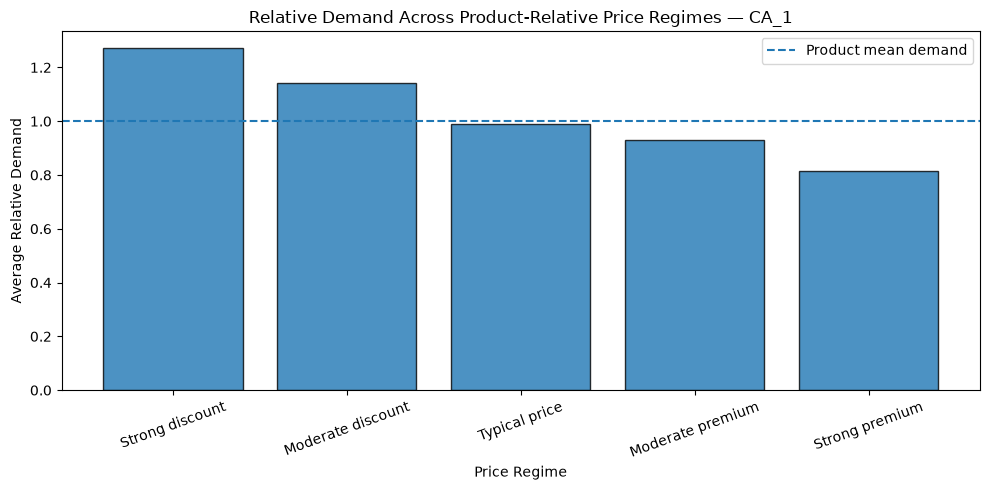

In [58]:
# ---------------------------------------------------------
# Visualize normalized demand across price regimes
# ---------------------------------------------------------
# The categories are kept in increasing relative-price order
# so that the relationship between price position and demand
# can be interpreted from left to right.

price_regime_order = [
    "Strong discount",
    "Moderate discount",
    "Typical price",
    "Moderate premium",
    "Strong premium",
]

plot_data = (
    price_regime_demand
    .set_index("price_regime")
    .reindex(price_regime_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["price_regime"],
    plot_data["average_relative_demand"],
    edgecolor="black",
    alpha=0.8
)

# A relative-demand value of 1 represents the historical
# mean demand level for a product.
plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Product mean demand"
)

plt.title("Relative Demand Across Product-Relative Price Regimes — CA_1")
plt.xlabel("Price Regime")
plt.ylabel("Average Relative Demand")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Monthly and Seasonal Demand Patterns

Earlier analysis identified a strong day-of-week effect and a longer-term
increase in CA_1 demand.

This section examines whether demand also varies systematically across months
of the year. Identifying recurring monthly patterns can help determine whether
month, season, or related calendar variables should be included during feature
engineering.

Because the historical period includes partial years, monthly demand is
evaluated using average daily sales rather than total monthly sales.

In [59]:
# ---------------------------------------------------------
# Add calendar month information to daily store demand
# ---------------------------------------------------------
# We work with the daily store-level series rather than the
# item-level dataset because the objective is to understand
# broad seasonal demand patterns at CA_1.
#
# Average daily sales will later be used instead of monthly
# totals so that months with different numbers of days remain
# comparable.

monthly_daily_sales = daily_sales.copy()

monthly_daily_sales["year"] = (
    monthly_daily_sales["date"].dt.year
)

monthly_daily_sales["month"] = (
    monthly_daily_sales["date"].dt.month
)

monthly_daily_sales["month_name"] = (
    monthly_daily_sales["date"].dt.strftime("%B")
)


# ---------------------------------------------------------
# Summarize demand by calendar month
# ---------------------------------------------------------
# Each month is represented across multiple years. The mean
# therefore describes the typical daily demand observed in
# that calendar month across the historical period.
#
# Median demand is retained because unusual dates such as
# Christmas can influence monthly averages.

monthly_demand = (
    monthly_daily_sales
    .groupby(
        [
            "month",
            "month_name",
        ],
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
    )
    .reset_index()
    .sort_values("month")
    .reset_index(drop=True)
)

monthly_demand

,month,month_name,number_of_days,average_daily_sales,median_daily_sales
0,1,January,158,3877.746835,3653.5
1,2,February,170,3900.911765,3805.0
2,3,March,186,3939.887097,3803.0
3,4,April,180,4079.722222,3920.5
4,5,May,177,4073.830508,3995.0
5,6,June,150,4168.380000,3989.0
6,7,July,155,4181.103226,4106.0
7,8,August,155,4290.903226,4146.0
8,9,September,150,4137.173333,3938.5
9,10,October,155,4057.270968,3957.0


In [60]:
# ---------------------------------------------------------
# Calculate average daily demand for each year
# ---------------------------------------------------------
# CA_1 demand increases over the historical period. Using a
# year-specific baseline helps separate recurring monthly
# patterns from this longer-term growth trend.
#
# Note that 2011 and 2016 are partial years, so their baselines
# describe only the observed portions of those years.

yearly_baseline = (
    monthly_daily_sales
    .groupby(
        "year",
        observed=True
    )["total_sales"]
    .mean()
    .rename("year_average_daily_sales")
    .reset_index()
)


# ---------------------------------------------------------
# Attach the annual baseline to each daily observation
# ---------------------------------------------------------

monthly_adjusted = monthly_daily_sales.merge(
    yearly_baseline,
    on="year",
    how="left",
    validate="many_to_one"
)


# ---------------------------------------------------------
# Calculate demand deviation from the corresponding year
# ---------------------------------------------------------
# Positive values indicate demand above that year's average,
# while negative values indicate demand below that year's
# average.
#
# This removes much of the long-term level difference between
# earlier and later years before comparing calendar months.

monthly_adjusted["year_deviation_pct"] = (
    (
        monthly_adjusted["total_sales"]
        - monthly_adjusted["year_average_daily_sales"]
    )
    / monthly_adjusted["year_average_daily_sales"]
    * 100
)


# ---------------------------------------------------------
# Summarize the year-adjusted pattern by calendar month
# ---------------------------------------------------------
# Mean and median deviations are both reported because
# individual holidays can produce unusually high or low
# demand on particular dates.

monthly_adjusted_summary = (
    monthly_adjusted
    .groupby(
        [
            "month",
            "month_name",
        ],
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_year_deviation_pct=(
            "year_deviation_pct",
            "mean"
        ),
        median_year_deviation_pct=(
            "year_deviation_pct",
            "median"
        ),
    )
    .reset_index()
    .sort_values("month")
    .reset_index(drop=True)
)

monthly_adjusted_summary

,month,month_name,number_of_days,average_year_deviation_pct,median_year_deviation_pct
0,1,January,158,-8.369704,-11.079217
1,2,February,170,-3.961442,-8.856864
2,3,March,186,-3.191787,-9.176050
3,4,April,180,0.106384,-6.386455
4,5,May,177,0.108769,-3.645575
5,6,June,150,4.262196,-1.535636
6,7,July,155,4.627442,0.778660
7,8,August,155,7.161255,0.802384
8,9,September,150,3.538304,-2.060990
9,10,October,155,1.913366,-3.633965


In [61]:
# ---------------------------------------------------------
# Restrict the analysis to complete calendar years
# ---------------------------------------------------------
# The historical dataset contains partial observations for
# 2011 and 2016. Restricting the analysis to 2012–2015 gives
# every calendar month equal representation across four
# complete years and provides a cleaner seasonality check.

complete_years = monthly_daily_sales[
    monthly_daily_sales["year"].between(2012, 2015)
].copy()


# ---------------------------------------------------------
# Calculate a separate demand baseline for each complete year
# ---------------------------------------------------------
# Each day's sales will be compared with the average daily
# demand of the same year, reducing contamination from the
# longer-term growth trend.

complete_year_baseline = (
    complete_years
    .groupby(
        "year",
        observed=True
    )["total_sales"]
    .mean()
    .rename("year_average_daily_sales")
    .reset_index()
)


complete_years = complete_years.merge(
    complete_year_baseline,
    on="year",
    how="left",
    validate="many_to_one"
)


# ---------------------------------------------------------
# Calculate year-adjusted daily demand
# ---------------------------------------------------------

complete_years["year_deviation_pct"] = (
    (
        complete_years["total_sales"]
        - complete_years["year_average_daily_sales"]
    )
    / complete_years["year_average_daily_sales"]
    * 100
)


# ---------------------------------------------------------
# Summarize monthly seasonality across complete years
# ---------------------------------------------------------
# With four complete years, each calendar month is represented
# consistently and is less affected by dataset boundaries.

complete_year_monthly_summary = (
    complete_years
    .groupby(
        [
            "month",
            "month_name",
        ],
        observed=True
    )
    .agg(
        number_of_days=("date", "count"),
        average_year_deviation_pct=(
            "year_deviation_pct",
            "mean"
        ),
        median_year_deviation_pct=(
            "year_deviation_pct",
            "median"
        ),
    )
    .reset_index()
    .sort_values("month")
    .reset_index(drop=True)
)

complete_year_monthly_summary

,month,month_name,number_of_days,average_year_deviation_pct,median_year_deviation_pct
0,1,January,124,-9.792798,-11.794948
1,2,February,113,-5.638450,-9.995114
2,3,March,124,-3.275744,-8.199634
3,4,April,120,0.140847,-6.504284
4,5,May,124,0.935762,-3.010274
5,6,June,120,6.401688,-0.031498
6,7,July,124,5.994223,2.882522
7,8,August,124,9.583705,2.253651
8,9,September,120,4.977140,-1.841240
9,10,October,124,0.451605,-5.027971


### Monthly Seasonality Findings

CA_1 exhibits a recurring monthly demand pattern after accounting for the
longer-term increase in sales.

To reduce distortion from the partial 2011 and 2016 periods, monthly
seasonality was re-evaluated using only the complete calendar years from
2012 through 2015. The resulting pattern is consistent with the analysis of
the full historical period.

Demand is relatively weak at the beginning of the year. January averages
approximately 9.8% below its corresponding annual demand level, followed by
February at approximately 5.6% below and March at approximately 3.3% below.

Demand strengthens through spring and becomes highest during the summer.
June averages approximately 6.4% above its annual baseline, July
approximately 6.0% above, and August approximately 9.6% above. September
also remains elevated at approximately 5.0% above the annual baseline.

Demand subsequently declines toward the end of the year, with November and
December averaging approximately 4.0% and 6.0% below their corresponding
annual demand levels.

Median deviations are generally less extreme than the monthly averages,
indicating that some high-demand days contribute disproportionately to the
mean seasonal pattern. Nevertheless, the recurring progression from weaker
early-year demand to stronger summer demand and lower year-end demand
indicates that calendar-month information may provide useful predictive
information for forecasting.

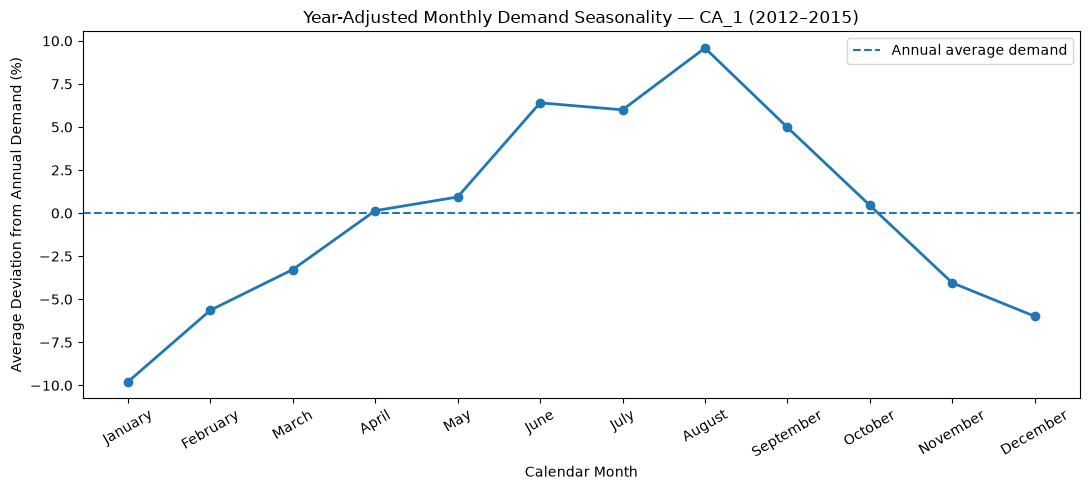

In [62]:
# ---------------------------------------------------------
# Visualize year-adjusted monthly seasonality
# ---------------------------------------------------------
# Only complete calendar years (2012–2015) are used so that
# each month receives consistent historical representation.
#
# The horizontal zero line represents the average daily
# demand level within each year.

plt.figure(figsize=(11, 5))

plt.plot(
    complete_year_monthly_summary["month_name"],
    complete_year_monthly_summary["average_year_deviation_pct"],
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Annual average demand"
)

plt.title(
    "Year-Adjusted Monthly Demand Seasonality — CA_1 (2012–2015)"
)
plt.xlabel("Calendar Month")
plt.ylabel("Average Deviation from Annual Demand (%)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# EDA Summary and Modeling Implications

The exploratory analysis of CA_1 reveals several important characteristics
that should guide the forecasting strategy.

### 1. Demand changes substantially over time

Daily store demand shows a clear long-term increase across the historical
period, although the growth is not linear. Shorter periods of rising and
falling demand are superimposed on this longer-term trend.

Forecasting models should therefore incorporate recent historical demand
rather than assuming a constant demand level.

### 2. Strong weekly seasonality is present

Demand varies substantially by day of the week. Weekend demand is considerably
higher than midweek demand, with Sunday recording the highest average sales
and Wednesday the lowest.

Day-of-week information and lagged demand at weekly intervals are therefore
likely to provide useful predictive information.

### 3. Product hierarchy captures meaningful demand differences

FOODS accounts for approximately 70% of total CA_1 unit sales, and FOODS_3
alone contributes approximately 51%.

Demand behavior also differs substantially between departments, indicating
that category and department identifiers contain useful information beyond
individual product identity.

### 4. Product demand is highly intermittent

Approximately 55% of available item-day observations record zero sales.
The median product records zero demand on approximately 58% of its available
days.

Intermittency differs substantially across departments. HOBBIES_2 has a
zero-sales rate above 84%, while FOODS_3 has a considerably lower rate of
approximately 41%.

Forecasting models must therefore handle both frequently purchased products
and highly sparse demand series.

### 5. Availability and zero demand represent different states

Missing price observations correspond to unavailable product periods and do
not contain positive sales.

These observations should remain distinguishable from days when a product was
available but recorded zero customer demand. Availability should therefore be
retained explicitly during feature engineering and model evaluation.

### 6. Calendar events contain useful information

Demand varies around calendar events, but individual events exhibit
substantially different patterns.

Labor Day is associated with considerably above-baseline demand, while
Thanksgiving and Christmas show large negative deviations. Christmas records
zero CA_1 sales throughout the observed period.

Event names should therefore be retained rather than representing all events
with only a single binary indicator.

### 7. SNAP status is associated with higher demand

SNAP days have higher average demand than non-SNAP days. The difference
remains after accounting for the strong weekday pattern.

The California SNAP indicator should therefore be retained as a potential
forecasting feature.

### 8. Prices are generally stable but promotions are important

Fewer than 1% of comparable item-week observations contain a price change.
However, some products experience substantial temporary markdowns.

Conventional percentage price changes become unstable when prices approach
zero. Product-relative price measures, discount depth, absolute changes, or
log-based transformations are therefore preferable to unrestricted percentage
changes.

### 9. Relative price is associated with relative demand

After normalizing demand within products, strongly discounted weeks exhibit
demand approximately 27% above the product-specific historical mean.

Relative demand progressively declines as prices move upward, reaching
approximately 18% below the product-specific mean during strong-premium
price periods.

This is a descriptive association rather than a causal estimate of price
elasticity, but it indicates that product-relative price contains potentially
useful forecasting information.

### 10. Monthly seasonality remains after accounting for long-term growth

Analysis of the complete calendar years 2012–2015 shows weaker demand during
the beginning and end of the year and stronger demand during summer.

January averages approximately 9.8% below its annual demand baseline, while
August averages approximately 9.6% above.

Calendar-month information may therefore provide additional seasonal
predictive information.

## Implications for Feature Engineering

The EDA suggests that the forecasting dataset should include several groups
of predictors:

- lagged historical demand at multiple horizons;
- rolling demand statistics;
- day-of-week and broader calendar features;
- month and seasonal information;
- event names and event types;
- SNAP status;
- product hierarchy identifiers;
- product availability;
- current and historical price information;
- product-relative price and discount features.

Because this is a forecasting problem, model validation must preserve temporal
ordering. Random train-test splitting would allow future observations to
influence evaluation and should therefore be avoided.

The next phase will construct these features using only information that would
be available at the time a forecast is generated.